In [63]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


## Install and Import Seaborn

In [64]:
import seaborn as sns

In [65]:
# filter for Data Analyst jobs in US:
df_da_us = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

# drop NaN values from the 'salary_year-avg' column for accurate visualization

df_da_us = df_da_us.dropna(subset=['salary_year_avg'])

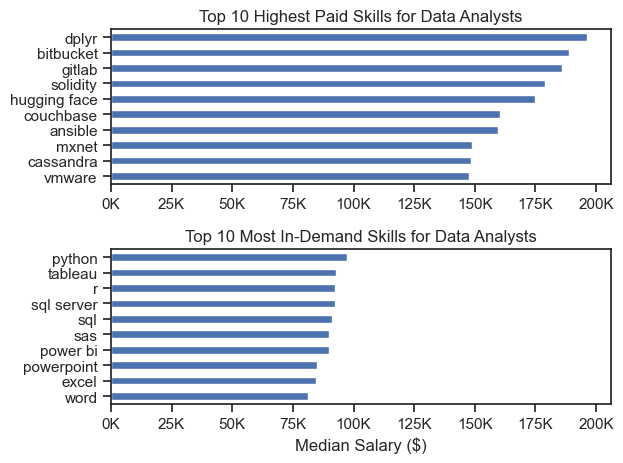

In [52]:
df_da_us = df_da_us.explode('job_skills')
df_da_us_group = df_da_us.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])
df_da_top_pay = df_da_us_group.sort_values(by='median', ascending = False).head(10)
df_da_skills = df_da_us_group.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending = False)

# since we are plotting two plots we need to run subplot function 

fig, ax = plt.subplots(2, 1)

df_da_top_pay.plot(kind = 'barh', y='median', ax=ax[0], legend = False)
ax[0].invert_yaxis()
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))


df_da_skills.plot(kind = 'barh', y='median', ax=ax[1], legend = False)
ax[1].invert_yaxis()
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary ($)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax[1].set_xlim(ax[0].get_xlim())
fig.tight_layout()
plt.show()


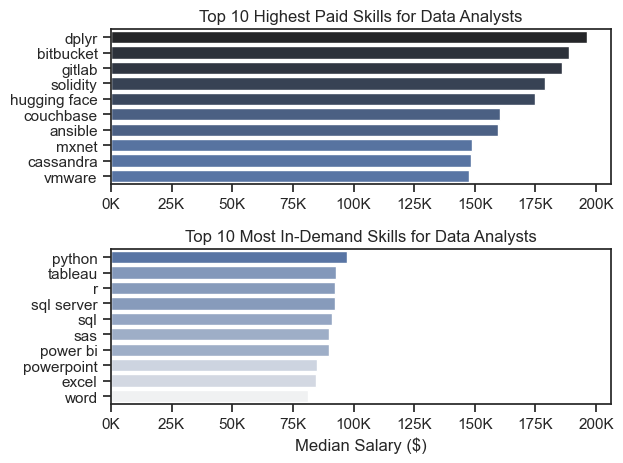

In [53]:
fig, ax = plt.subplots(2, 1)

sns.set_theme(style = "ticks")
sns.barplot(data=df_da_top_pay, x='median', y=df_da_top_pay.index, ax=ax[0], hue='median', palette='dark:b_r')

# df_da_top_pay.plot(kind = 'barh', y='median', ax=ax[0], legend = False)
# ax[0].invert_yaxis()
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax[0].legend().remove()

# df_da_skills.plot(kind = 'barh', y='median', ax=ax[1], legend = False)

sns.barplot(data=df_da_skills, x='median', y=df_da_skills.index, ax=ax[1], hue='median', palette='light:b')

# ax[1].invert_yaxis()
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary ($)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax[1].set_xlim(ax[0].get_xlim())
ax[1].legend().remove()
fig.tight_layout()
plt.show()

TypeError: 'str' object is not callable

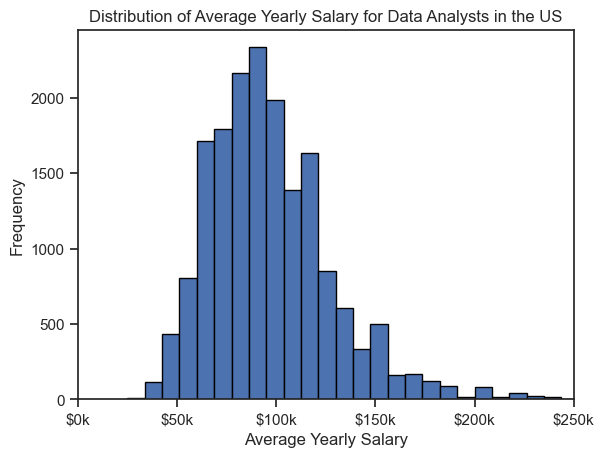

In [54]:
df_da_us['salary_year_avg'].plot(kind='hist', bins=40 ,edgecolor = 'black')
plt.xlim(0, 250000)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))

plt.title('Distribution of Average Yearly Salary for Data Analysts in the US')
plt.xlabel('Average Yearly Salary')
plt.ylabel('Total Jobs')

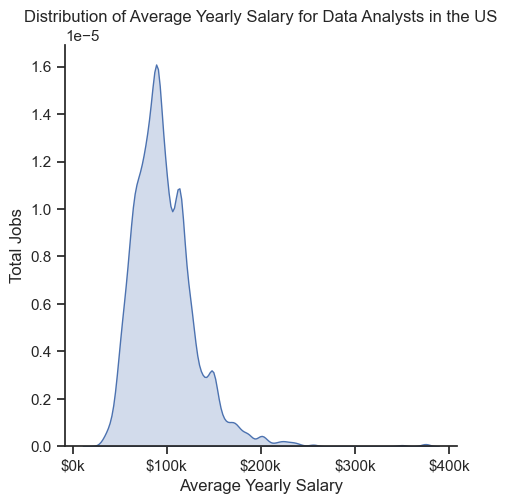

In [ ]:
# df_da_us['salary_year_avg'].plot(kind='hist', bins=40 ,edgecolor = 'black')
# plt.xlim(0, 250000)
sns.displot(df_da_us['salary_year_avg'], kind = 'kde', fill = True)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))

plt.title('Distribution of Average Yearly Salary for Data Analysts in the US')
plt.xlabel('Average Yearly Salary')
plt.ylabel('Total Jobs')
plt.show()

C:\Users\tom-i\AppData\Local\Temp\ipykernel_46316\1307158368.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


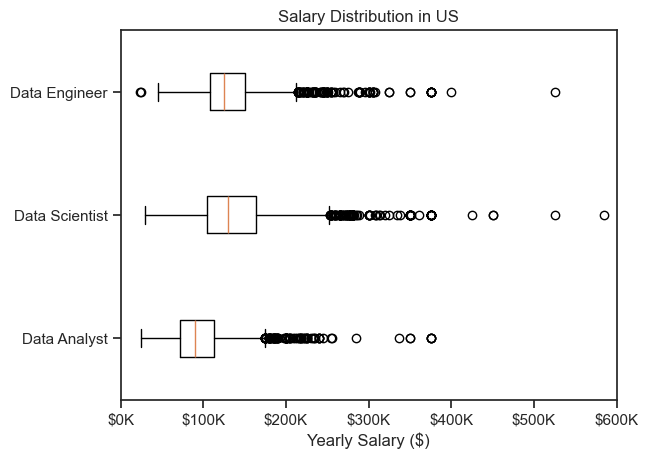

In [ ]:
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

df_us = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()

df_us = df_us.dropna(subset=['salary_year_avg'])

job_list = [df_us[df_us['job_title_short'] == job_titles]['salary_year_avg'] for job_titles in job_titles]

plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title('Salary Distribution in US')
plt.xlabel('Yearly Salary ($)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 600000)
plt.show()

TypeError: 'str' object is not callable

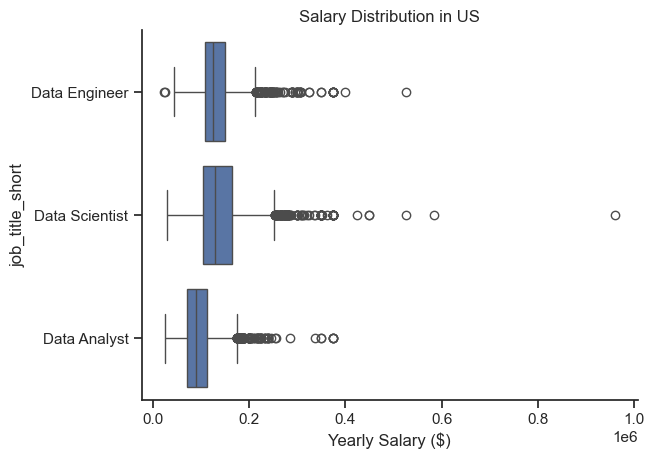

In [ ]:
sns.boxplot(data=df_us, x='salary_year_avg', y='job_title_short')

# plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title('Salary Distribution in US')
# sns.despine()
plt.xlabel('Yearly Salary ($)')
plt.ylabel('')
plt.xlim(0, 600000)

# ax = plt.gca()
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)

plt.show()

In [ ]:
# Not sure why it is causing an error when trying to remove y_label